<center>
<h1> TP-Projet d'optimisation numérique </h1>
<h1> Algorithme du lagrangien augmenté </h1>
</center>

## Implémentation

1. Implémenter l'algorithme du lagrangien augmenté, en utilisant les différentes méthodes
qui ont été vues en première partie pour la résolution de la suite de problèmes sans
contraintes (fichier `src/lagrangien_augmente.jl`). La spécification est donnée dans le fichier.
2. Vérifier que les tests ci-dessous passent.
 

In [1]:
include("../src/lagrangien_augmente.jl")
include("../test/tester_lagrangien_augmente.jl")

afficher = true

tester_lagrangien_augmente(lagrangien_augmente, afficher);

Affichage des résultats des algorithmes : true

-------------------------------------------------------------------------
Résultats de : LA et newton appliqué à f1:
  * x0       = [0, 1, 1]
  * x_sol    = [0.5000042424566808, 1.2499978787716595, 0.5000042424566811]
  * f(x_sol) = 2.249961818051857
  * nb_iters = 7
  * flag     = 0
  * solution = [0.5, 1.25, 0.5]
-------------------------------------------------------------------------
Résultats de : LA et newton appliqué à f1:
  * x0       = [0.5, 1.25, 1.0]
  * x_sol    = [0.5000042424566808, 1.2499978787716595, 0.5000042424566811]
  * f(x_sol) = 2.249961818051857
  * nb_iters = 7
  * flag     = 0
  * solution = [0.5, 1.25, 0.5]
-------------------------------------------------------------------------
Résultats de : LA et newton appliqué à f2:
  * x0       = [1, 0]
  * x_sol    = [0.9072338874848903, 0.8227553232868374]
  * f(x_sol) = 0.00861566424194443
  * nb_iters = 5
  * flag     = 0
  * solution = [0.9072339605110892, 0.822755456

## Interprétation

1. Commenter les résultats obtenus, en étudiant notamment les valeurs en sortie de $\lambda_k$ et $\mu_k$.

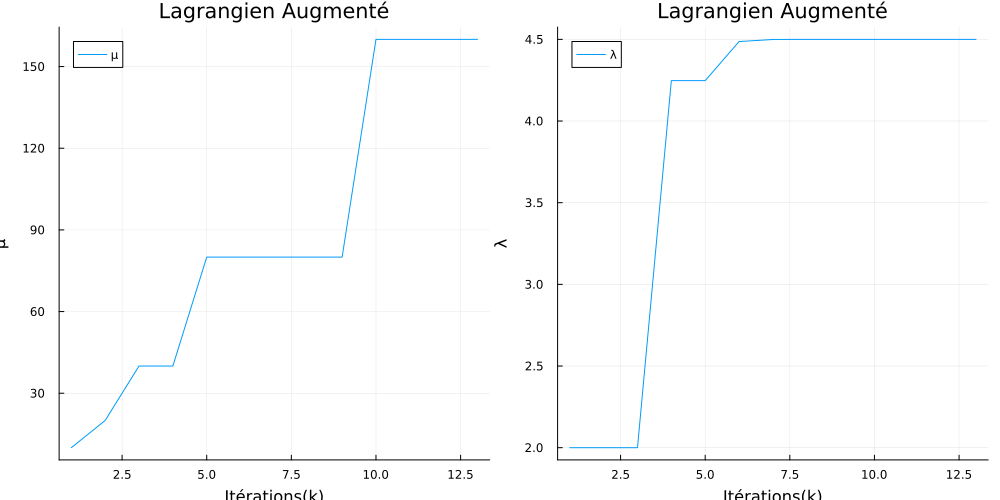

In [5]:
using Plots
include("../src/lagrangien_augmente.jl")

# Fonction f1
# -----------
f1(x) = 2 * (x[1] + x[2] + x[3] - 3)^2 + (x[1] - x[2])^2 + (x[2] - x[3])^2
gradf1(x) = [4 * (x[1] + x[2] + x[3] - 3) + 2 * (x[1] - x[2]); # dérivée /x1
              4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[1] - x[2]) + 2 * (x[2] - x[3]); # dérivée /x2
              4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[2] - x[3])] # dérivée /x3
hessf1(x) = [6 2 4; 2 8 2; 4 2 6]
solution = [1; 1; 1]

# contrainte extraite de test/fonctions_de_tests.jl
c(x) = x[1] + x[3] - 1
gradc(x) = [1; 0; 1]
hessc(x) = [0 0 0; 0 0 0; 0 0 0]

x0 = [0; 0; 0]

x_sol, f_sol, flag, nb_iters, μs, λs = lagrangien_augmente(f1, gradf1, hessf1, c, gradc, hessc, x0)
pμ = plot(μs, label="μ", ylabel="μ", xlabel="Itérations(k)")
pλ = plot(λs, label="λ", ylabel="λ", xlabel="Itérations(k)")
p = plot(pμ, pλ, layout=(1,2), size=(1000, 500), title="Lagrangien Augmenté")
display(p)

 2. Étudier l'influence du paramètre $\tau$ dans la performance de l'algorithme. Pour cela Vous réaliserez des tests numériques.

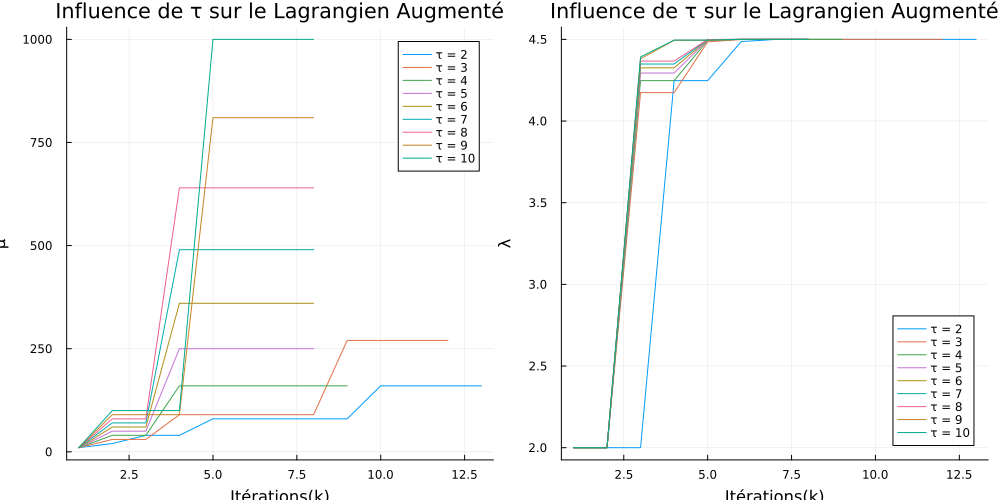

In [8]:
pμ = plot(title="Lagrangien Augmenté", xlabel="Itérations(k)", ylabel="μ")
pλ = plot(title="Lagrangien Augmenté", xlabel="Itérations(k)", ylabel="λ")

x0 = [0; 0; 0]
for τ in [2:10;]
    x_sol, f_sol, flag, nb_iters, μs, λs = lagrangien_augmente(f1, gradf1, hessf1, c, gradc, hessc, x0, τ=τ)
    plot!(pμ, μs, label="τ = $τ")
    plot!(pλ, λs, label="τ = $τ")
end

p = plot(pμ, pλ, layout=(1,2), size=(1000, 500), title="Influence de τ sur le Lagrangien Augmenté")
display(p)